### LINEAR REGRESSION
In this hands-on tryout notebook, we try to model the 'Estimated Price' as a linear relation of the other elements

In [52]:
# Importing libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### CLASSES IN PYTHON

In [53]:
class LinearRegression:
    def __init__(self) -> None:
        '''
        Constructor for the class
        Defines member variables weights and bias and initializes them to zero
        They can be accessed in other functions of the class by using self.weights and self.bias
        '''
        self.weights: np.ndarray | None = None
        self.bias: float | None = None
    


    ### TODO 1
    def predict(self, X: np.ndarray) -> np.ndarray:
        '''
        Computes the predicted values based on calculated weights and bias given an input array
        
        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
        
        Returns:
            An array of predicted values Y_pred (np.ndarray)
        '''
        # YOUR CODE HERE
        return X.dot(self.weights) + self.bias


    ### TODO 2 
    def __loss(self, X: np.ndarray, y: np.ndarray, norm: int,regularized_lemda : float) -> tuple:
        '''
        The loss function is a variant of Minkowski distance.
        Minkowski distance between X and Y is defined as:
            (1 / n) * [sum(abs(xi - yi) ^ p)]
        Return the loss, and gradients with respect to the weights and bias
        
        Args:
            X_input (np.ndarray): Feature matrix of shape (n_samples, n_features).
            Y_expected (np.ndarray): Target vector of shape (n_samples,).
            norm (int): Order of Minkowski distance.
            regularized(float) : Gives the regualrized lemda value.
        
        Returns:
            tuple: loss, dw, db
        '''

        n = X.shape[0]
        y_pred = self.predict(X)
        diff = y - y_pred
        

        # It is the minkoski loss (norm = p)
        loss = (1/n) * np.sum(np.abs(y - y_pred) ** norm)
        l2_penelty = (regularized_lemda / (2 *n))*(np.sum(np.square(self.weights)))
        loss = loss + l2_penelty

        # only dw is regualized here as regularization of db will not effect much oftenly not done.

        # Generlly which we used Gradients for MSE (norm = 2)
        if norm ==2:
            dw = (-2 /n) *(X.T  @ (y-y_pred))
            db = (-2/n) * np.sum(y-y_pred)
        else:
            dw = (-norm/n) * (X.T  @(np.abs(diff) ** (norm - 1) * np.sign(diff)))
            db = (-norm/n) * (np.sum(np.abs(diff) ** (norm-1)* np.sign(diff)))
        
        dw_penelty = (regularized_lemda / n)* self.weights
        dw = dw + dw_penelty

        return loss, dw, db
    


    ### TODO 3
    def fit(self, X: np.ndarray, y: np.ndarray, epochs: int = 500, learning_rate: float = 0.01, norm: int = 2, threshold: float = 0.0001, lemda_reg : float = 0.01) -> None:
        '''
        Applies gradient descent on the given data and tunes the values of the weights and bias

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
            y (np.ndarray): Target vector of shape (n_samples,).
            epochs (int): Maximum number of iterations of gradient descent.
            learning_rate (float): Constant which alters the rate of convergence
            norm (int): Norm for the loss function
            threshold (float): Stops the gradient descent if the change in loss or cost is below this value
            lambda_reg (float): Regularization constant (Apply L1 regularization)

        Returns:
            None
        '''
        n_features  = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        prev_loss = float('inf')
        # Initialize weights randomly and set up gradient descent
        # YOUR CODE HERE
        
        for _ in range(epochs):
            # Logic for gradient descent (use the loss function to get gradients)
            # YOUR CODE HERE
            loss ,dw , db = self.__loss(X,y,norm , lemda_reg)
            self.weights = self.weights - learning_rate *dw
            self.bias = self.bias - learning_rate * db

            if(abs(prev_loss - loss) <= threshold):
                break

            prev_loss = loss
    
    def r2_score(self, X: np.ndarray, y: np.ndarray) -> float:
        '''
        Calculates the R-squared (coefficient of determination) score of the model.

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
            y (np.ndarray): True target vector of shape (n_samples,).

        Returns:
            float: The R-squared score.
        '''
        # First, get the model's predictions for the given data
        y_pred = self.predict(X)

        # Calculate the Total Sum of Squares (SST)
        # This is the variance of the true y values around their mean
        y_mean = np.mean(y)
        sst = np.sum((y - y_mean) ** 2)

        # Calculate the Residual Sum of Squares (SSR)
        # This is the error of our model
        ssr = np.sum((y - y_pred) ** 2)

        # Calculate the R-squared score
        # Add a small epsilon to the denominator to prevent division by zero for constant datasets
        if sst == 0:
            return 1.0 if ssr == 0 else 0.0
        
        r2 = 1 - (ssr / sst)
        
        return r2



### Importing and Converting Data

Here is the link to the dataset:
https://drive.google.com/file/d/1Kdg4_YZKtjjzxq5qYbhOYsqM7LoInAq2/view?usp=sharing 

Some features in a dataset are not of numerical type and are either categorical or boolean.  
To get past this, we convert the columns by using one-hot encoding.

In [54]:
# importing the data
df = pd.read_csv('linear_data.csv')




### TODO 4
# convert columns from categorical/boolean to integer (use one-hot encoding)

df['Manual Transmission'] = df['Manual Transmission'].astype(int)

# what get dummies does is it makes new unique columns of that column
df = pd.get_dummies(df, columns=['Fuel'], drop_first=True)

df['Fuel_Diesel'] = df['Fuel_Diesel'].astype(int)
df['Fuel_Petrol'] = df['Fuel_Petrol'].astype(int)
df['Fuel_EV'] = df['Fuel_EV'].astype(int)

print(df.head())
# YOUR CODE HERE

data = df.to_numpy()

X = df.drop(columns=['Estimated Price']).to_numpy()
y = df['Estimated Price'].to_numpy()

print(X.shape)
print(y.shape)

   Original Price  Miles Driven    Mileage  Tank Size  HorsePower  Top Speed  \
0         3864000          1263  54.685799  13.336164         596        180   
1         4288000           752  35.248357  19.057518         419        185   
2         2966000          4838  58.345711  28.361993         346        259   
3         3428000          3140  34.654196  24.024602         354        243   
4         2079000          4048  32.048424  17.980987         473        216   

   Acceleration  Age  Manual Transmission  Estimated Price  Fuel_Diesel  \
0      8.172050    4                    0     2.258675e+06            0   
1      8.740271    3                    1     2.859767e+06            0   
2      6.533210    5                    1     1.333506e+06            1   
3      6.069808    4                    1     2.046536e+06            1   
4      7.744648    2                    0     1.204469e+06            1   

   Fuel_EV  Fuel_Petrol  
0        0            1  
1        0      

### Test-train split
Overfitting is one of the biggest problems in machine learning. Overfitting occurs when the model is trained to be very accurate on the given dataset but performs very poorly on a different but similar dataset.
To check for overfitting, we split our dataset into test and train sets and check the accuracy/loss of the model.

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Z-Score Standardization
Since some features might have much higher values than the others, for weights of similar magnitude, the model will mainly focus only on features with large values.  
To overcome this, we standardize each feature using Z-Score Standardization so that all features are treated equally

In [56]:
# z-score standardization
### TODO 5
def z_score(X: np.ndarray) -> tuple:
    '''
    The Z-Score scales data such that its mean is 0 and standard deviation is 1
    z-score for a value x in the dataset is (x - mean) / std_dev
    (z-score normalization is done over a feature and NOT an entry)
    Return the z-score value of all the elements in the set along with the mean and standard deviation of the original set
    '''

    # Add code here
    x_mean = np.mean(X,axis=0) # along each row aas we for each row if we dodn't specified then it would have done whole column
    x_std =np.std(X,axis=0)
    x = (X - x_mean)/x_std
    return x, x_mean, x_std

In [57]:
# Normalizing the data
x_train, x_mean, x_std = z_score(X_train)
x_test = (X_test - x_mean) / x_std

MSE loss:  4619489.980787005
0.9999897678944574


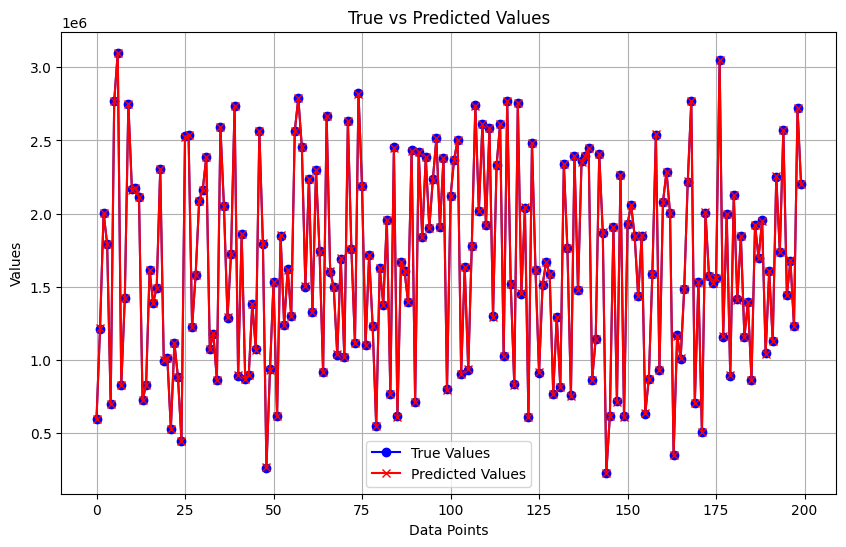

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train, epochs=500, learning_rate=0.01, norm=2, threshold=0.0001,lemda_reg=0.01)
y_pred = model.predict(x_test)
print("MSE loss: ", np.mean((y_pred - y_test) ** 2))
r2_test = model.r2_score(x_test, y_test)
print(r2_test)

indices = np.arange(len(y_test))
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test, label='True Values', color='blue', marker='o')
plt.plot(indices, y_pred, label='Predicted Values', color='red', marker='x')

plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('True vs Predicted Values')

plt.legend()
plt.grid(True)
plt.show()



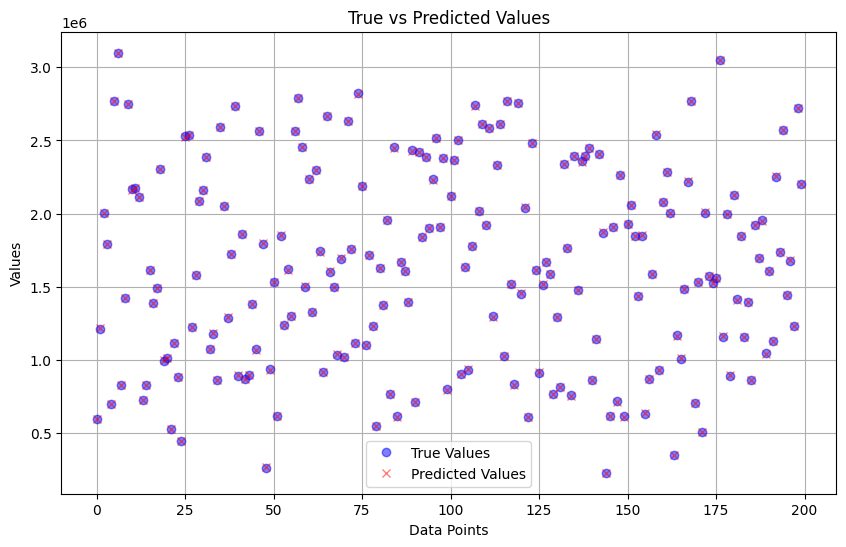

In [59]:
indices = np.arange(len(y_test))
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test, label='True Values', color='blue', marker='o', linestyle='None', alpha=0.5)
plt.plot(indices, y_pred, label='Predicted Values', color='red', marker='x', linestyle='None', alpha=0.5)
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()